**Netflix Content Analyis**


Project Overview-
This project analyses Netflix's content catalogue to identify trends in content type, geographical distribution, genres, release patterns, ratings, and director contributions.

Using Python and Pandas, the dataset was cleaned, explored, and visualised to generate business insights and recommendations that could support strategic content decisions.

**Business Objectives**

The aim of this project is to answer the following questions:

- What proportion of Netflix's catalogue consists of Movies versus TV Shows?
- Which countries contribute the most content?
- Which genres are the most common?
- How has Netflix's content library evolved over time?
- Which content ratings dominate the platform?
- Which directors have contributed the most titles?

**Data Cleaning**
Before analysis, the dataset was cleaned by:

- Removing unnecessary unnamed columns
- Identifying missing values
- Checking data types
- Removing duplicate records (if any)
- Converting date columns into a suitable format

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [3]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(8809, 26)

In [6]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df["type"].value_counts()

,count
type,
Movie,6132
TV Show,2677


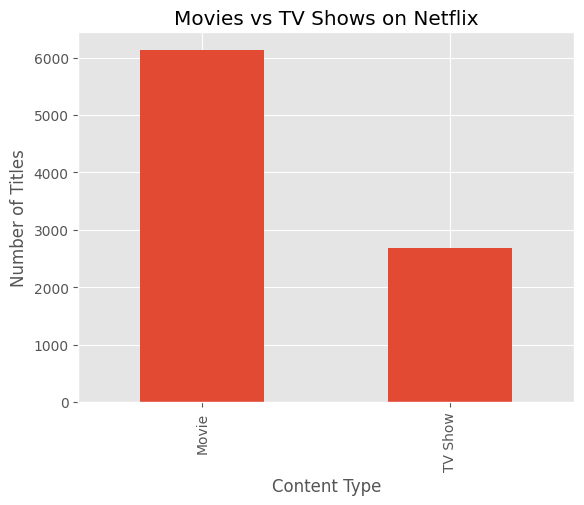

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.savefig("movies_vs_tvshows.png", dpi=300, bbox_inches="tight")

plt.show()

from google.colab import files
files.download("movies_vs_tvshows.png")






Movies make a significantly larger portion of the catalogue as compared to the TV shows,suggesting the company has invested heavily on movies than shows


In [11]:
top_countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

top_countries

,count
country,
United States,3690
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,232
Germany,226


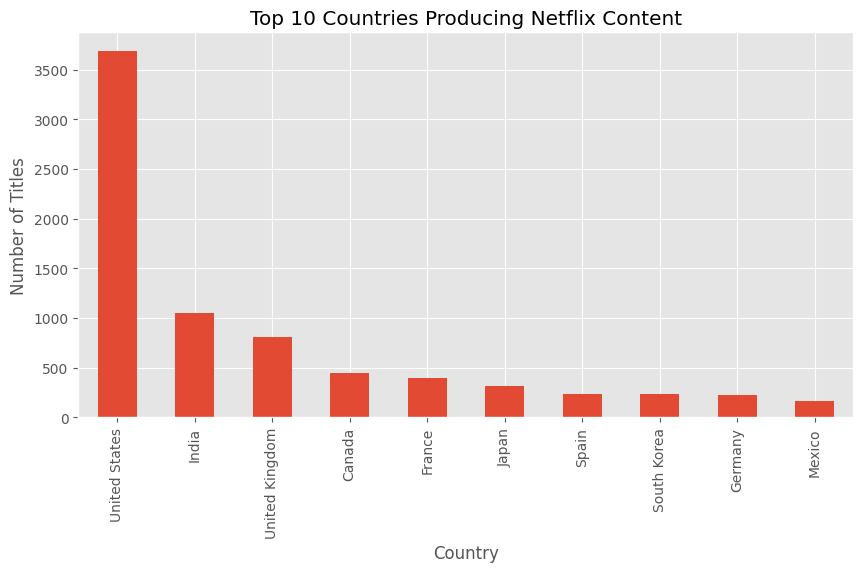

In [12]:
top_countries.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()



1.  Observation-The United States contributes the highest number of titles, followed by countries such as India and the United Kingdom.List item
2. Insight-Netflix's content library is heavily concentrated in a few countries, reflecting its largest production markets and audience bases.


3. Analysis-Investing in original productions from underrepresented regions could diversify the catalogue and attract a broader global audience.


In [13]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


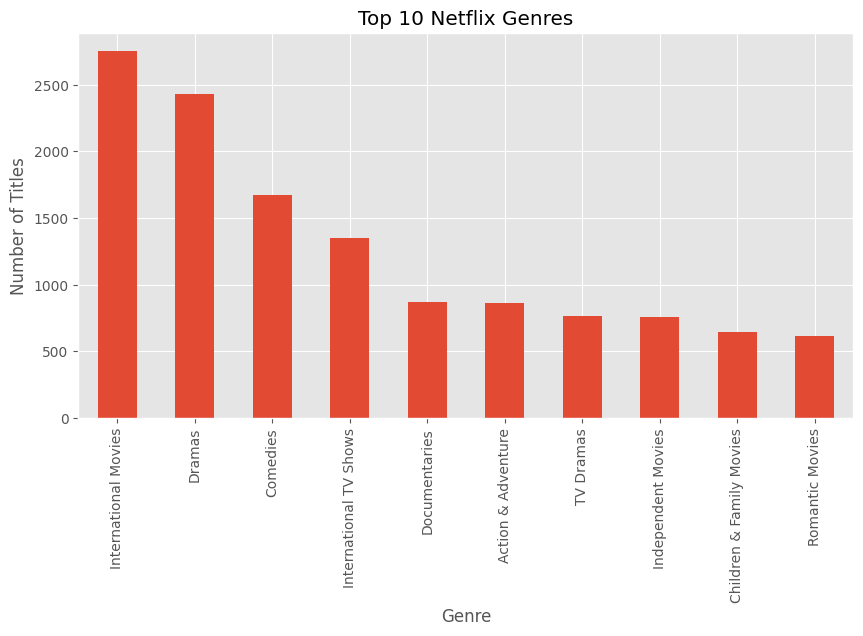

In [14]:
genres.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.show()



1.  Observation-
Drama, International Movies, and Comedies are among the most common genres available on Netflix.

2.  Insight-
Netflix prioritizes genres with broad international appeal and high viewer demand across multiple markets.
3.  Analysis-
Continuing to invest in high-performing genres while experimenting with niche genres could improve user satisfaction and content diversity.






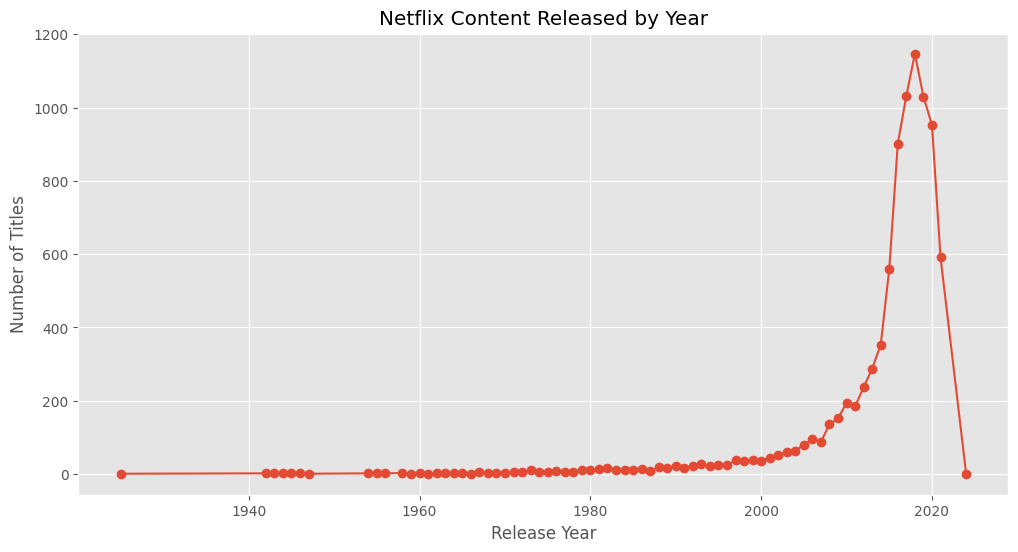

In [15]:
content_by_year = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(content_by_year.index, content_by_year.values, marker="o")

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()



1.  Observation-The number of Netflix titles released over the year grows steadily with a rapid growth in 2015.
2.  Insight-
Netflix significantly expanded its content library during this period, aligning with its global expansion and increased investment in original programming.
3.  Analysis-Analysing whether recently added content generates higher engagement can help optimise future content acquisition strategies






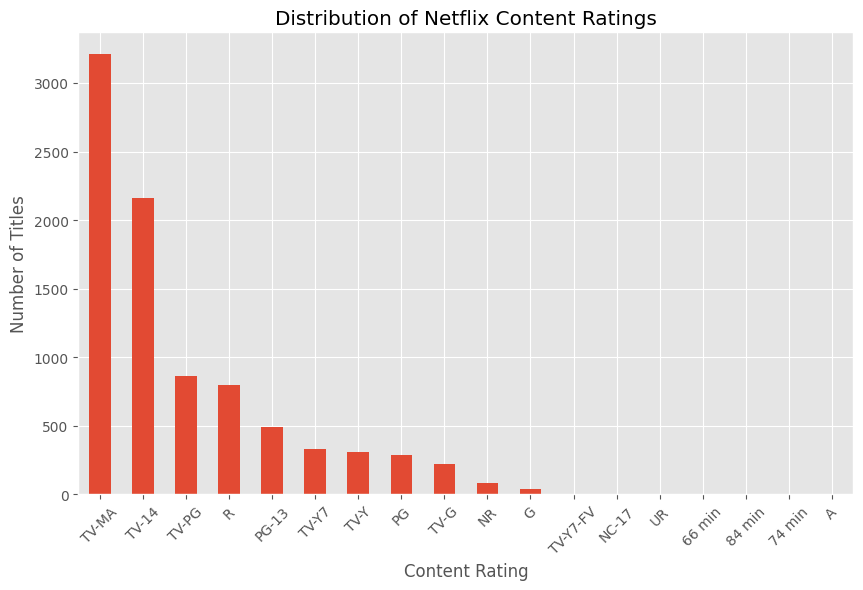

In [16]:
ratings = df["rating"].value_counts()

plt.figure(figsize=(10,6))

ratings.plot(kind="bar")

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()



1.  Observation-
TV-MA is the most frequent content rating.


2.  Insight-
Netflix primarily targets mature audiences by offering a substantial amount of adult-oriented content.


3.  Analysis-
Increasing high-quality family-friendly content may help attract and retain households with children.



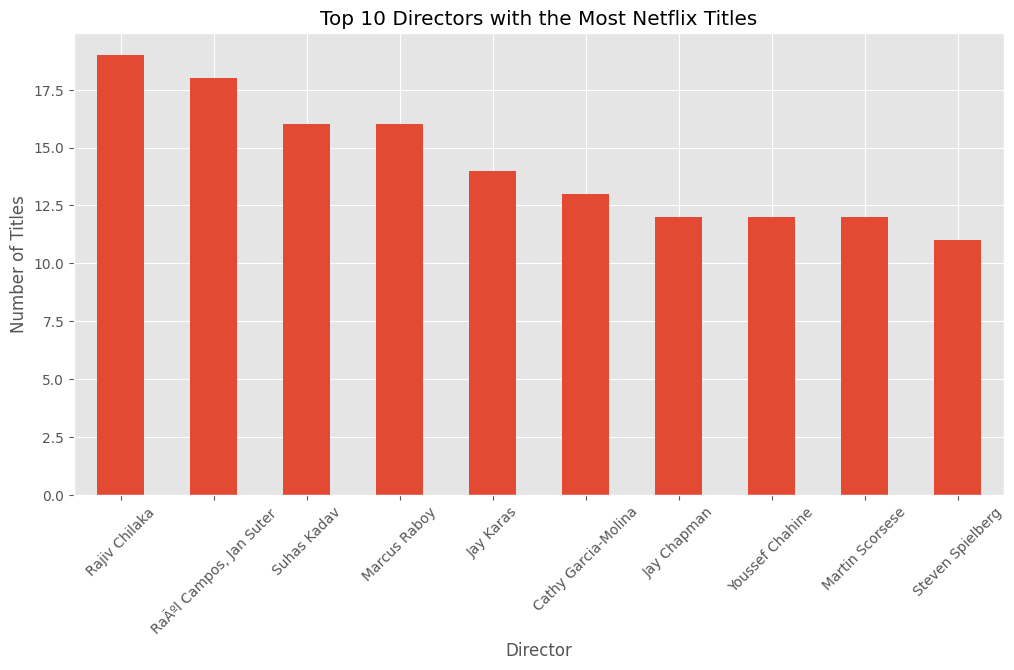

In [17]:
top_directors = (
    df["director"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_directors.plot(kind="bar")

plt.title("Top 10 Directors with the Most Netflix Titles")
plt.xlabel("Director")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()



1. Observation-
A small number of directors appear repeatedly across Netflix's catalogue.

2.  Insight-
Netflix maintains ongoing relationships with certain directors who consistently contribute content to the platform.

3.  Analysis-
Expanding partnerships with successful directors while discovering emerging filmmakers could help balance consistency with innovation.






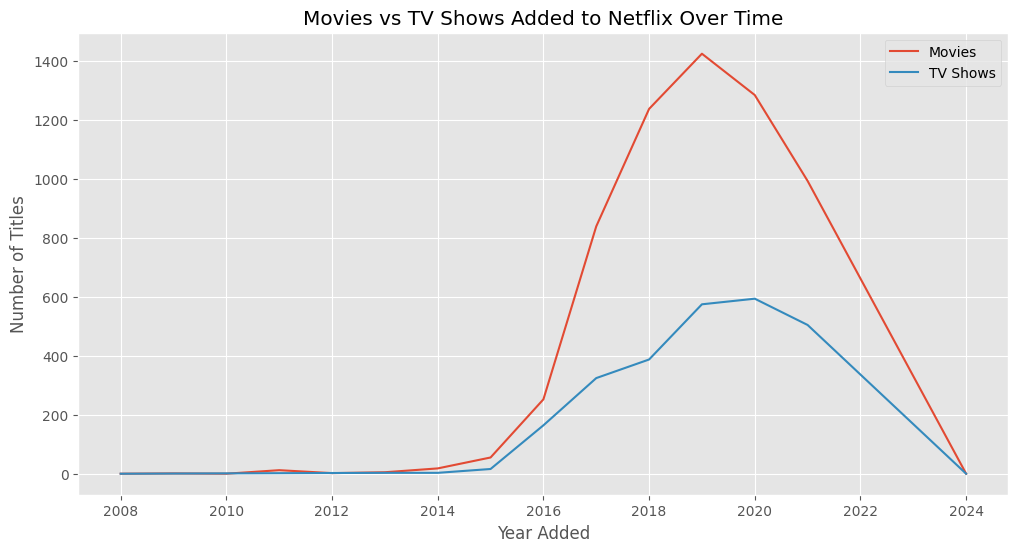

In [18]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["year_added"] = df["date_added"].dt.year

movies = df[df["type"] == "Movie"]["year_added"].value_counts().sort_index()
tvshows = df[df["type"] == "TV Show"]["year_added"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(movies.index, movies.values, label="Movies")
plt.plot(tvshows.index, tvshows.values, label="TV Shows")

plt.title("Movies vs TV Shows Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend()

plt.grid(True)

plt.show()



1.  Observation-
Both movies and TV shows increased significantly after 2015, although movies consistently outnumber TV shows.
2.   Insight-
Netflix rapidly expanded both categories during its global growth phase while maintaining a stronger focus on movies.


3.  Analysis-
Continued investment in high-quality TV series could improve long-term subscriber engagement due to binge-watching behaviour.






**Executive Summary**

The analysis revealed several important insights:

- Movies significantly outnumber TV Shows.
- The United States contributes the largest share of Netflix content.
- Drama and International Movies dominate the catalogue.
- Netflix experienced rapid content growth after 2015.
- Mature-rated content represents a significant portion of the library.
- Netflix collaborates repeatedly with several high-performing directors.

These findings demonstrate how exploratory data analysis can support business decisions related to content acquisition and platform growth.